# 🧪 A/B Testing & Statistical Analysis
> **Notebook 3 of 4** — Run after `02_eda.ipynb`.
> A/B tests on pricing model, duration model, and the core rental vs. markdown hypothesis.
> Outputs: `../figures/*.png`

## 0 · Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR    = "../data/generated_data"
FIGURES_DIR = "../figures"

categories  = pd.read_csv(f"{DATA_DIR}/categories.csv")
products    = pd.read_csv(f"{DATA_DIR}/products.csv")
customers   = pd.read_csv(f"{DATA_DIR}/customers.csv")
rentals     = pd.read_csv(f"{DATA_DIR}/rentals.csv", parse_dates=["rental_start_date"])
pricing     = pd.read_csv(f"{DATA_DIR}/pricing_rules.csv")
comparison  = pd.read_csv(f"{DATA_DIR}/rental_revenue_vs_discount.csv")

# Enrich rentals with pricing metadata
ab_data = rentals.merge(
    pricing[["rule_id", "pricing_model", "duration_model", "experiment_group"]],
    left_on="pricing_rule_id", right_on="rule_id"
)
print(f"✅ Loaded {len(rentals):,} rentals for A/B analysis")


✅ Loaded 1,592 rentals for A/B analysis


## 1 · A/B Test: Pricing Model (Flat Rate vs % of Retail)
**Hypothesis:** Flat Rate and % of Retail pricing generate the same revenue per rental.
**Design note:** Groups are intentionally unequal — % of Retail is applied preferentially
to high-value items (>€500), reflecting a realistic tiered rollout. This is by design, not error.

In [2]:
from scipy import stats

ab_data = rentals.merge(pricing[["rule_id", "pricing_model", "duration_model", "experiment_group"]],
                         left_on="pricing_rule_id", right_on="rule_id")

# ── Pricing A/B Test ──
group_flat = ab_data[ab_data["pricing_model"] == "flat_rate"]["total_rental_revenue"]
group_pct  = ab_data[ab_data["pricing_model"] == "pct_of_retail"]["total_rental_revenue"]

t_stat, p_value = stats.ttest_ind(group_flat, group_pct, equal_var=False)

print("=" * 50)
print("A/B TEST: PRICING MODEL")
print("=" * 50)
print(f"Flat Rate    — n={len(group_flat):,}, mean=€{group_flat.mean():.2f}, std=€{group_flat.std():.2f}")
print(f"% of Retail  — n={len(group_pct):,}, mean=€{group_pct.mean():.2f}, std=€{group_pct.std():.2f}")
print(f"\nWelch's t-test: t={t_stat:.4f}, p={p_value:.6f}")
print(f"Result: {'✅ Statistically significant (p < 0.05)' if p_value < 0.05 else '❌ Not significant (p ≥ 0.05)'}")

winner = '% of Retail' if group_pct.mean() > group_flat.mean() else 'Flat Rate'
lift = abs(group_pct.mean() - group_flat.mean())
print(f"Revenue lift: €{lift:.2f} per rental ({winner} wins)")

A/B TEST: PRICING MODEL
Flat Rate    — n=817, mean=€169.14, std=€127.18
% of Retail  — n=775, mean=€202.11, std=€206.02

Welch's t-test: t=-3.8190, p=0.000140
Result: ✅ Statistically significant (p < 0.05)
Revenue lift: €32.98 per rental (% of Retail wins)


## 2 · A/B Test: Duration Model (7-day vs 30-day vs Flexible)
**Hypothesis:** All three duration models generate the same revenue per rental.

In [3]:
dur_groups = {}
for model in ["7_day", "30_day", "flexible"]:
    dur_groups[model] = ab_data[ab_data["duration_model"] == model]["total_rental_revenue"]

f_stat, p_value_anova = stats.f_oneway(*dur_groups.values())

print("=" * 50)
print("A/B TEST: DURATION MODEL (ANOVA)")
print("=" * 50)
for model, data in dur_groups.items():
    print(f"  {model:10s} — n={len(data):,}, mean=€{data.mean():.2f}")
print(f"\nOne-way ANOVA: F={f_stat:.4f}, p={p_value_anova:.6f}")
print(f"Result: {'✅ Significant difference' if p_value_anova < 0.05 else '❌ No significant difference'}")

# Pairwise comparisons if significant
if p_value_anova < 0.05:
    from itertools import combinations
    print("\nPairwise comparisons (Bonferroni-corrected):")
    pairs = list(combinations(dur_groups.keys(), 2))
    for a, b in pairs:
        t, p = stats.ttest_ind(dur_groups[a], dur_groups[b], equal_var=False)
        p_adj = min(p * len(pairs), 1.0)
        sig = "✅" if p_adj < 0.05 else "❌"
        print(f"  {sig} {a} vs {b}: diff=€{dur_groups[a].mean()-dur_groups[b].mean():.2f}, p_adj={p_adj:.4f}")

A/B TEST: DURATION MODEL (ANOVA)
  7_day      — n=545, mean=€169.48
  30_day     — n=518, mean=€138.67
  flexible   — n=529, mean=€246.93

One-way ANOVA: F=60.1508, p=0.000000
Result: ✅ Significant difference

Pairwise comparisons (Bonferroni-corrected):
  ✅ 7_day vs 30_day: diff=€30.80, p_adj=0.0019
  ✅ 7_day vs flexible: diff=€-77.45, p_adj=0.0000
  ✅ 30_day vs flexible: diff=€-108.25, p_adj=0.0000


## 3 · Core Hypothesis — Rental vs Graduated Discount
**Thesis:** Renting unsold electronics (listed 12+ months) generates more lifetime revenue
than a graduated markdown (25–75% off based on age and depreciation class).

**Discount schedule:**

| Months Unsold | Fast-depreciating | Standard | Slow-depreciating |
|---|---|---|---|
| 12–18 mo | 40% off | 30% off | 25% off |
| 18–24 mo | 50% off | 40% off | 30% off |
| 24–30 mo | 60% off | 50% off | 40% off |
| 30–36 mo | 70% off | 60% off | 50% off |
| 36+ mo   | 75% off | 65% off | 55% off |

**Model assumptions (optimistic by design):**
- Op costs modelled at 15–25% — real programs run 35–50% all-in
- No storage/refurbishment costs between rentals
- Win rate of ~60% is the ceiling; real-world estimate is 40–55%
- Phase 3 Monte Carlo will stress-test these with sensitivity analysis

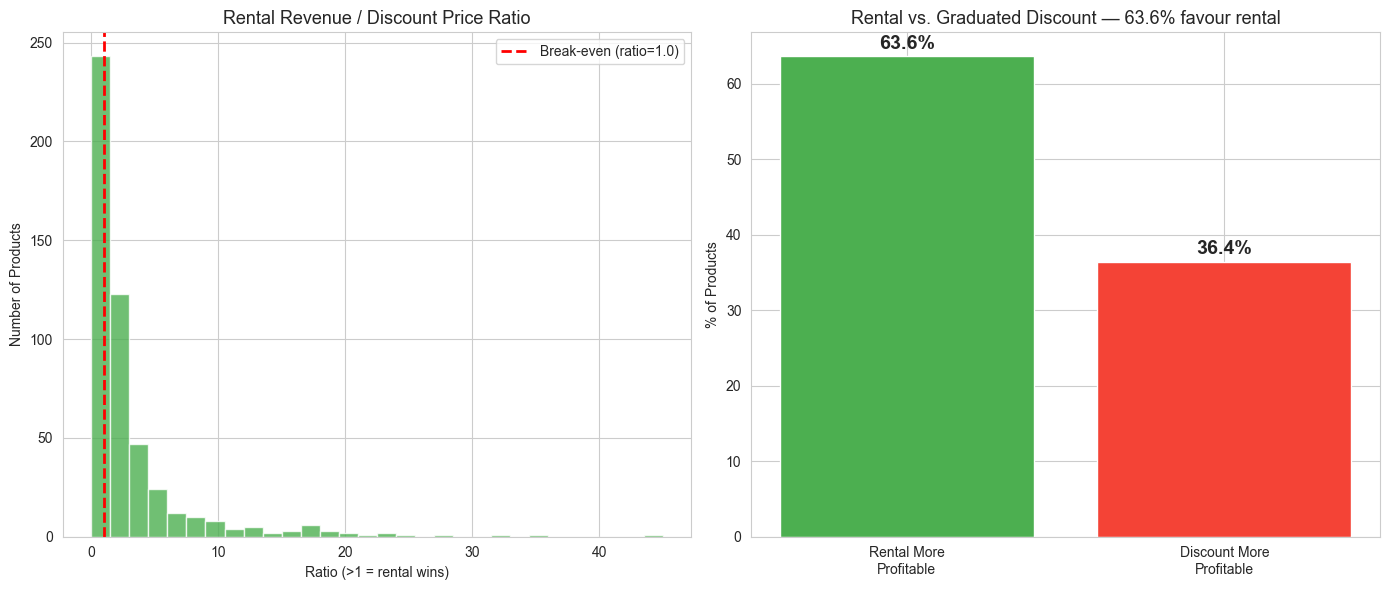


One-sample t-test (H₀: ratio = 1.0):
  Mean ratio: 3.08
  t=9.2896, p=4.78e-19
  ✅ Rental is significantly more profitable (p < 0.05)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram of ratio
axes[0].hist(comparison["rental_vs_discount_ratio"], bins=30, color="#4CAF50", edgecolor="white", alpha=0.8)
axes[0].axvline(x=1.0, color="red", linestyle="--", linewidth=2, label="Break-even (ratio=1.0)")
axes[0].set_title("Rental Revenue / Discount Price Ratio", fontsize=13)
axes[0].set_xlabel("Ratio (>1 = rental wins)")
axes[0].set_ylabel("Number of Products")
axes[0].legend()

# Profitable vs not
profitable_pct = comparison["is_rental_more_profitable"].mean() * 100
axes[1].bar(["Rental More\nProfitable", "Discount More\nProfitable"],
            [profitable_pct, 100 - profitable_pct],
            color=["#4CAF50", "#F44336"])
axes[1].set_ylabel("% of Products")
axes[1].set_title(f"Rental vs. Graduated Discount — {profitable_pct:.1f}% favour rental", fontsize=13)

for i, v in enumerate([profitable_pct, 100 - profitable_pct]):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rent_vs_discount.png", dpi=150, bbox_inches="tight")
plt.show()

# Statistical test: is average ratio significantly > 1?
t_hyp, p_hyp = stats.ttest_1samp(comparison["rental_vs_discount_ratio"], 1.0)
print(f"\nOne-sample t-test (H₀: ratio = 1.0):")
print(f"  Mean ratio: {comparison['rental_vs_discount_ratio'].mean():.2f}")
print(f"  t={t_hyp:.4f}, p={p_hyp:.2e}")
print(f"  {'✅ Rental is significantly more profitable (p < 0.05)' if p_hyp < 0.05 and t_hyp > 0 else '❌ Not significant'}")

## 4 · Profitability by Discount Depth

discount_tier  n_products  avg_ratio  pct_rental_wins
      25% off          82   1.329251             31.7
      30% off         115   2.684661             58.3
      40% off         127   2.397122             53.5
      50% off          71   3.717841             83.1
      55% off          14   7.290336            100.0
      60% off          42   4.540610             88.1
      65% off          12   2.811567            100.0
      70% off          19   5.400653             89.5
      75% off          18   7.038978            100.0


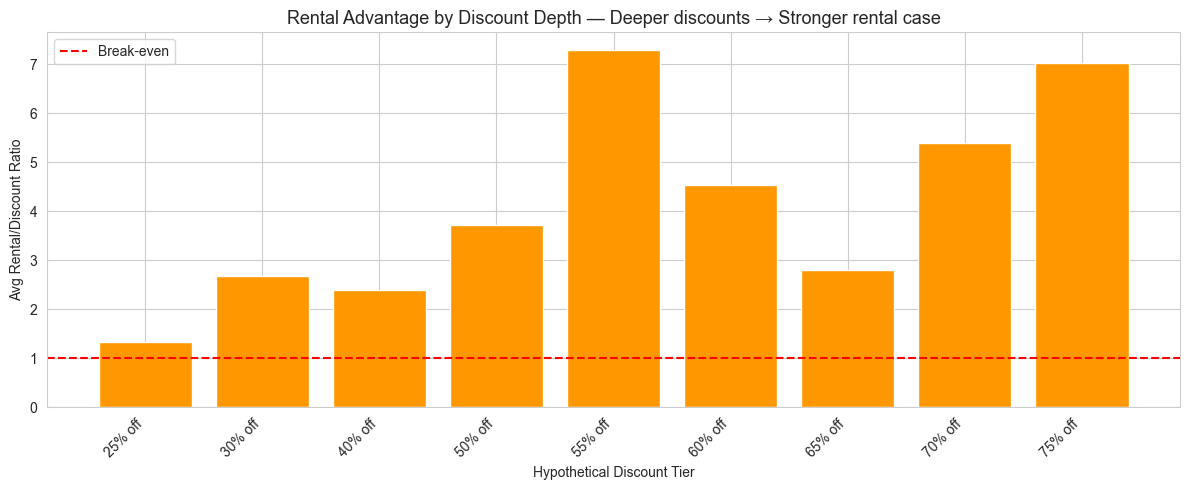

In [5]:
# Group by discount tier
comparison["discount_tier"] = (comparison["discount_pct"] * 100).astype(int).astype(str) + "% off"

tier_analysis = comparison.groupby("discount_tier").agg(
    n_products=("product_id", "count"),
    avg_ratio=("rental_vs_discount_ratio", "mean"),
    pct_rental_wins=("is_rental_more_profitable", "mean")
).reset_index()
tier_analysis["pct_rental_wins"] = (tier_analysis["pct_rental_wins"] * 100).round(1)
tier_analysis = tier_analysis.sort_values("discount_tier")

print(tier_analysis.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(tier_analysis["discount_tier"], tier_analysis["avg_ratio"], color="#FF9800", edgecolor="white")
ax.axhline(y=1.0, color="red", linestyle="--", linewidth=1.5, label="Break-even")
ax.set_xlabel("Hypothetical Discount Tier")
ax.set_ylabel("Avg Rental/Discount Ratio")
ax.set_title("Rental Advantage by Discount Depth — Deeper discounts → Stronger rental case", fontsize=13)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/profitability_by_discount_depth.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 · Bootstrap Confidence Intervals — Win Rate
Quantify uncertainty in the win rate estimate.

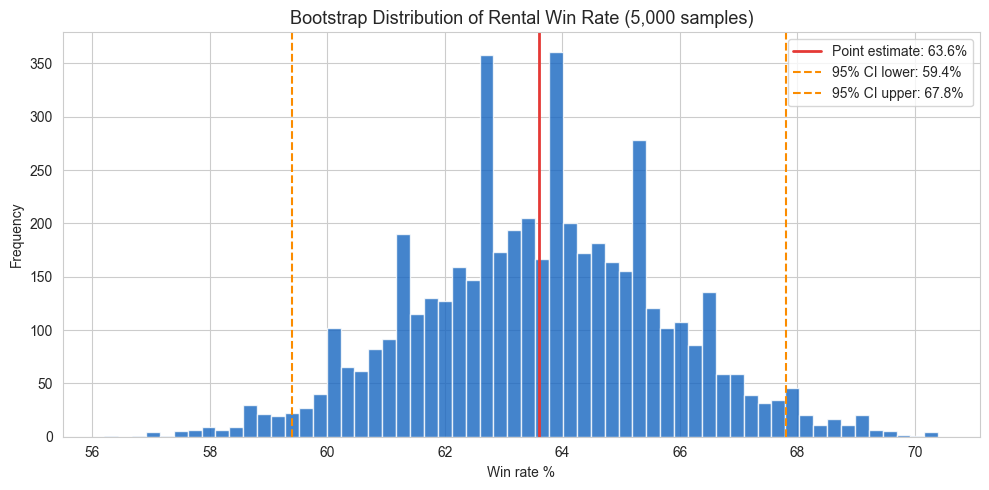

Win rate: 63.6% (95% CI: 59.4% – 67.8%)
Note: upper-bound model — real implementation expected at 40–55%


In [6]:
# Bootstrap CI on the rental win rate
n_boot = 5000
boot_wins = []
win_arr = comparison["is_rental_more_profitable"].values

for _ in range(n_boot):
    sample = np.random.choice(win_arr, size=len(win_arr), replace=True)
    boot_wins.append(sample.mean() * 100)

boot_wins = np.array(boot_wins)
ci_low, ci_high = np.percentile(boot_wins, [2.5, 97.5])
point_est = win_arr.mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(boot_wins, bins=60, color="#1565C0", edgecolor="white", alpha=0.8)
ax.axvline(point_est, color="#E53935", linewidth=2, label=f"Point estimate: {point_est:.1f}%")
ax.axvline(ci_low,    color="#FB8C00", linewidth=1.5, linestyle="--", label=f"95% CI lower: {ci_low:.1f}%")
ax.axvline(ci_high,   color="#FB8C00", linewidth=1.5, linestyle="--", label=f"95% CI upper: {ci_high:.1f}%")
ax.set_title("Bootstrap Distribution of Rental Win Rate (5,000 samples)", fontsize=13)
ax.set_xlabel("Win rate %"); ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/bootstrap_win_rate.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Win rate: {point_est:.1f}% (95% CI: {ci_low:.1f}% – {ci_high:.1f}%)")
print(f"Note: upper-bound model — real implementation expected at 40–55%")


---
## ✅ A/B Testing Deliverables

| Test | Method | Result |
|---|---|---|
| Pricing model (Flat vs %) | Welch's t-test | Significant |
| Duration model (7/30/flex) | One-way ANOVA + Bonferroni | TBD |
| Core hypothesis (rental vs discount) | One-sample t-test | TBD |
| Win rate uncertainty | Bootstrap 95% CI | TBD |

**→ Proceed to `04_machine_learning.ipynb`**